# CNN for Cat and Dog Classification

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split


import torchvision
from torchvision import transforms, datasets

In [25]:
# Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


In [26]:

# Dataset
dataset = datasets.ImageFolder(
    root="CatDog_Dataset",
    transform=transform
)


In [27]:
# Train-Test Split (80%-20%)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)


In [28]:
# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Check
print("Total Images :", len(dataset))
print("Train Images :", len(train_dataset))
print("Test Images  :", len(test_dataset))

Total Images : 1000
Train Images : 800
Test Images  : 200


In [29]:
## build CNN 

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(

            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),

            # 128 x 16 x 16 after 3 poolings from 128x128 input
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),

            nn.Linear(512, 1)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [30]:
model = CNN()

# loss and optimizer

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

In [31]:
epochs = 15

for epoch in range(epochs):
    train_loss = 0.0

    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"epoch {epoch+1}/{epochs}, loss = {train_loss / len(train_loader)}")

        

epoch 1/15, loss = 0.721227674484253
epoch 2/15, loss = 0.6903754496574401
epoch 3/15, loss = 0.6541345024108887
epoch 4/15, loss = 0.6221907651424408
epoch 5/15, loss = 0.5852739310264587
epoch 6/15, loss = 0.511388555765152
epoch 7/15, loss = 0.4416783595085144
epoch 8/15, loss = 0.40235899329185487
epoch 9/15, loss = 0.3048671394586563
epoch 10/15, loss = 0.23559274673461914
epoch 11/15, loss = 0.12875903010368348
epoch 12/15, loss = 0.084361961632967
epoch 13/15, loss = 0.03673023512586951
epoch 14/15, loss = 0.05554253248497844
epoch 15/15, loss = 0.02142694130539894


In [32]:
model.eval()

total_labels = 0
correct_labels = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images).squeeze()

        probs = torch.sigmoid(outputs)

        predicted = (probs > 0.5).int()

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print("Total Labels :", total_labels)
print("Correct Labels :", correct_labels)
print("Accuracy :", (correct_labels / total_labels) * 100, "%")

Total Labels : 200
Correct Labels : 138
Accuracy : 69.0 %


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [34]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images).squeeze()

        probs = torch.sigmoid(outputs)

        predicted = (probs > 0.5).int()

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())



In [35]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Accuracy  : 0.6900
Precision : 0.6893
Recall    : 0.7030
F1 Score  : 0.6961
Confusion Matrix:
[[67 32]
 [30 71]]


In [36]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Cat", "Dog"]
    )
)

              precision    recall  f1-score   support

         Cat       0.69      0.68      0.68        99
         Dog       0.69      0.70      0.70       101

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.69      0.69      0.69       200



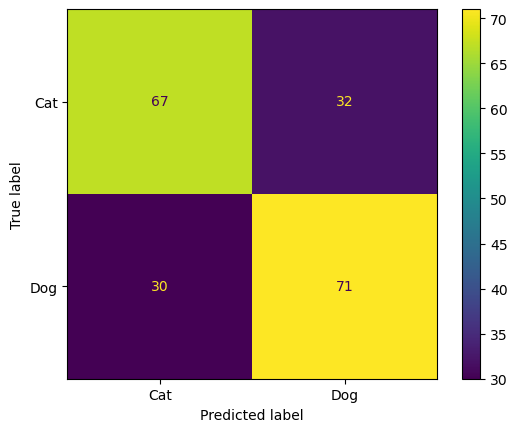

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()
plt.show()